<a href="https://colab.research.google.com/github/iamatulkumar-ya/data-science/blob/master/libraries/langchain/langgraph/langgraph_persistence.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# LangGraph Persistence

LangGraph Persistence: <i>LangGraph has a built-in persistence layer, implemented through checkpointers. When you compile a graph with a checkpointer, the checkpointer saves a checkpoint of the graph state at every super-step. Those checkpoints are saved to a thread, which can be accessed after graph execution. Because threads allow access to graph's state after execution, several powerful capabilities including human-in-the-loop, memory, time travel, and fault-tolerance are all possible. </i>

Documents:


*   https://docs.langchain.com/oss/python/langgraph/quickstart
*   https://docs.langchain.com/oss/python/langgraph/graph-api
*   https://docs.langchain.com/oss/python/langgraph/persistence



In simple words, persistence helps us to save the state for the workflow. It helps to resume from failed workflow, or rerun the completed workflow etc.

In [169]:
%%capture
!pip install langgraph
!pip install mermaid-py  # to visualise the graph

In [170]:
# defining grpah
# Stategraph is used to typed the output and share the state vars across multiple nodes
from langgraph.graph import StateGraph, END
# Using below lib for graph structure to visualize
import mermaid as md
# Below is the lib to render the image
from IPython.display import Image
from typing import Annotated, TypedDict
from IPython.core.compilerop import operator

In [171]:
# state class for graph state
class AgentState(TypedDict):
  messages: Annotated[list, operator.add] # declared the dict with annotated that each item get added as arrives

Creating functions to act as a node functionality

Let's assume we have approval system where we need several level of approvals. Then we can specify the nodes accordingly.

In [172]:
def first_node(state:AgentState):
  return  {"messages": ["First Approval Status: Approved"]}

def second_node(state:AgentState):
  return {"messages": ["Second Approval Status: Approved"]}

def third_node(state:AgentState):
  latestMsg = state["messages"][-1]

  if latestMsg == "Second Approval Status: Rejected":
    return  {"messages": ["Final Status: Rejected"]}
  else:
    return  {"messages": ["Final Status: Approved"]}

In [173]:
graph = StateGraph(AgentState)  # we must set schema, if we do not have any then we can set to dict

adding nodes

In [174]:
graph.add_node(first_node)
graph.add_node(second_node)
graph.add_node(third_node)

Creating edges, to connect two nodes

In [175]:
graph.add_edge("first_node", "second_node")
graph.add_edge("second_node", "third_node")
graph.add_edge("third_node", END)

Setting entry point and finish point for the graph

In [176]:
graph.set_entry_point("first_node")

Let's compile with persistence and invoke

### InMemory Persistence - Short Term Memory (Internal Flow)

Short-term memory (thread-level persistence) enables agents to track multi-turn conversations. To add short-term memory we use "checkpoint"

In [177]:
from langgraph.checkpoint.memory import InMemorySaver

<b>Checkpoint: </b> Checkpoints are simply checkpoints which get created as graph executes to store the state value.

In [178]:
# creating object for inmemorysaver to store the state value
memoryObj = InMemorySaver()

In [179]:
# now adding the checkpointer as memoryObj to store the graph states
app = workflow.compile(checkpointer=memoryObj)

let's view the graph structure

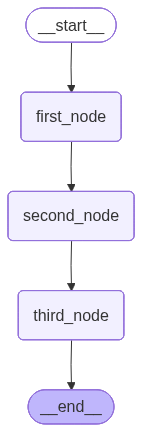

In [180]:
Image(app.get_graph().draw_mermaid_png())

In [181]:
input_text = {"messages": ["application for phone number update."]}

# now, before invoking, we must initialize the thread_id, which will be used to uniquely identify the execution
threadConfig = {"configurable": {"thread_id":"1"}}


<b>Threads: </b> So, threads are used to uniquely identify the graph execution. If we want to resume the executed graph, then we have to use thread_id of the previously executed graph.

In [182]:

output_text = app.invoke(input_text, threadConfig)

In [183]:
print(output_text)

{'messages': ['application for phone number update.', 'First Approval Status: Approved', 'Second Approval Status: Approved', 'Final Status: Approved']}


nice, let's see the state

In [184]:
app.get_state(threadConfig)

StateSnapshot(values={'messages': ['application for phone number update.', 'First Approval Status: Approved', 'Second Approval Status: Approved', 'Final Status: Approved']}, next=(), config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f0bfae5-90c3-6223-8003-fe1e1d27b2ee'}}, metadata={'source': 'loop', 'step': 3, 'parents': {}}, created_at='2025-11-12T09:59:58.767137+00:00', parent_config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f0bfae5-90c1-6a9e-8002-8139b1963613'}}, tasks=(), interrupts=())

In [185]:
list(app.get_state_history(threadConfig))

[StateSnapshot(values={'messages': ['application for phone number update.', 'First Approval Status: Approved', 'Second Approval Status: Approved', 'Final Status: Approved']}, next=(), config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f0bfae5-90c3-6223-8003-fe1e1d27b2ee'}}, metadata={'source': 'loop', 'step': 3, 'parents': {}}, created_at='2025-11-12T09:59:58.767137+00:00', parent_config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f0bfae5-90c1-6a9e-8002-8139b1963613'}}, tasks=(), interrupts=()),
 StateSnapshot(values={'messages': ['application for phone number update.', 'First Approval Status: Approved', 'Second Approval Status: Approved']}, next=('third_node',), config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f0bfae5-90c1-6a9e-8002-8139b1963613'}}, metadata={'source': 'loop', 'step': 2, 'parents': {}}, created_at='2025-11-12T09:59:58.766535+00:00', parent_config={'configurable': {'thread

Seems, simple right, but what is the magic here? To understand the power of persistence let's execute another run with different thread with some tweak.

### InMemory Persistence - Long Term Memory (Knowledge)


Use long-term memory to store user-specific or application-specific data across conversations. To add short-term memory we use "store".  store does not work as checkpointers. Only checkpointers will have the entry for state. So, we have to put the data into store for knowledge base, and if we want to store the checkpointers too, then we have to use that as well.


In [186]:
from langgraph.store.memory import InMemoryStore    # in memory store with key value pair
from langgraph.store.base import BaseStore
from langchain_core.runnables import RunnableConfig
from langgraph.config import get_store

<b>Store: </b>  persist across different threads or conversations.

In [187]:
# creating object for InMemoryStore to store the state value
storeMemoryObj = InMemoryStore()

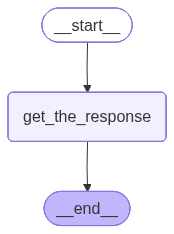

In [188]:
# creating a simple graph to understand the concept

def get_the_response(state: str, config : RunnableConfig ):

  current_user_id = config["configurable"]["user_id"]
  user_namespace = ("user_memories", current_user_id)
  baseStore: BaseStore = get_store()
  userMemories = baseStore.get(user_namespace, key=state)
  print("userMemories: ", userMemories)
  if userMemories:
    print("\nmemory found")
    return userMemories.value["response"]

    print("memory not found")

  # let's add the memory
  print("adding memory into store")
  baseStore.put(user_namespace, state, value={"response":"Query has been answered"})
  return "Query has been answered"


storeGraph = StateGraph(str)
storeGraph.add_node(get_the_response)

storeGraph.add_edge("get_the_response", END)
storeGraph.set_entry_point("get_the_response")

storeWorkFlow = storeGraph.compile(store=storeMemoryObj)

# let's view the simple graph
Image(storeWorkFlow.get_graph().draw_mermaid_png())


In [189]:
store_flow_input = "what is state in langgraph"

# need to create user name space for each user to store the knowledge

store_config = {
        "configurable": {
            "thread_id": "111",
            "user_id": "user111",
        }
    }

store_flow_output= storeWorkFlow.invoke(input=store_flow_input, config=store_config )
print(store_flow_output)

userMemories:  None
adding memory into store
Query has been answered


nice, let's ask again, with same input it must fetch from memory

In [190]:
store_flow_input = "what is state in langgraph"

# need to create user name space for each user to store the knowledge

store_config = {
        "configurable": {
            "thread_id": "111",
            "user_id": "user111",
        }
    }

store_flow_output= storeWorkFlow.invoke(input=store_flow_input, config=store_config )
print(store_flow_output)

userMemories:  Item(namespace=['user_memories', 'user111'], key='what is state in langgraph', value={'response': 'Query has been answered'}, created_at='2025-11-12T09:59:58.919349+00:00', updated_at='2025-11-12T09:59:58.919352+00:00')

memory found
Query has been answered


wow!!! let's ask the same question for different user. It must be adding new

In [191]:
store_flow_input = "what is state in langgraph"

# need to create user name space for each user to store the knowledge

store_config = {
        "configurable": {
            "thread_id": "111",
            "user_id": "user112",
        }
    }

store_flow_output= storeWorkFlow.invoke(input=store_flow_input, config=store_config )
print(store_flow_output)

userMemories:  None
adding memory into store
Query has been answered


nice, but here is the note, we are keep adding new key as "question" which is not good for in memory. Thus, we must use vector db or some other db to persist the memory.

### InMemory Persistence with Interruption and Resume

In [192]:
# let's interrupt the flow before third_node, so we can have human in the loop to pitch in and take some action before final approval.
intrptFlowApp = graph.compile(checkpointer=InMemorySaver(), interrupt_before=["third_node"]) # initialized that, flow must interrupt before third node



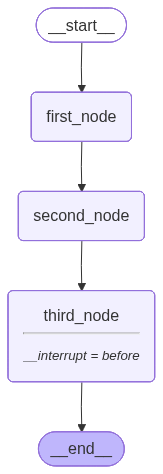

In [193]:
# let's visualize the graph flow
display(Image(intrptFlowApp.get_graph().draw_mermaid_png()))

In [194]:
input_text2 = {"messages": ["applciation for address update."]}

# now, before invoking, we must initialize the thread_id, which will be used to uniquely identify the execution
threadConfig2 = {"configurable": {"thread_id":"2"}}

output_text2 = intrptFlowApp.invoke(input_text2, threadConfig2)
print(output_text2)



{'messages': ['applciation for address update.', 'First Approval Status: Approved', 'Second Approval Status: Approved']}


Perfect, our flow ran till second approval only, now let's look into the state and the state history

In [195]:
intrptFlowApp.get_state(threadConfig2)

StateSnapshot(values={'messages': ['applciation for address update.', 'First Approval Status: Approved', 'Second Approval Status: Approved']}, next=('third_node',), config={'configurable': {'thread_id': '2', 'checkpoint_ns': '', 'checkpoint_id': '1f0bfae5-936f-67f0-8002-3b08b7019c6d'}}, metadata={'source': 'loop', 'step': 2, 'parents': {}}, created_at='2025-11-12T09:59:59.047449+00:00', parent_config={'configurable': {'thread_id': '2', 'checkpoint_ns': '', 'checkpoint_id': '1f0bfae5-9369-6cf5-8001-d877960d0ef1'}}, tasks=(PregelTask(id='e50d1d75-d819-ca13-83e5-239bffc33d72', name='third_node', path=('__pregel_pull', 'third_node'), error=None, interrupts=(), state=None, result=None),), interrupts=())

In [196]:
thread2StateHistory = list(intrptFlowApp.get_state_history(threadConfig2))
thread2StateHistory

[StateSnapshot(values={'messages': ['applciation for address update.', 'First Approval Status: Approved', 'Second Approval Status: Approved']}, next=('third_node',), config={'configurable': {'thread_id': '2', 'checkpoint_ns': '', 'checkpoint_id': '1f0bfae5-936f-67f0-8002-3b08b7019c6d'}}, metadata={'source': 'loop', 'step': 2, 'parents': {}}, created_at='2025-11-12T09:59:59.047449+00:00', parent_config={'configurable': {'thread_id': '2', 'checkpoint_ns': '', 'checkpoint_id': '1f0bfae5-9369-6cf5-8001-d877960d0ef1'}}, tasks=(PregelTask(id='e50d1d75-d819-ca13-83e5-239bffc33d72', name='third_node', path=('__pregel_pull', 'third_node'), error=None, interrupts=(), state=None, result=None),), interrupts=()),
 StateSnapshot(values={'messages': ['applciation for address update.', 'First Approval Status: Approved']}, next=('second_node',), config={'configurable': {'thread_id': '2', 'checkpoint_ns': '', 'checkpoint_id': '1f0bfae5-9369-6cf5-8001-d877960d0ef1'}}, metadata={'source': 'loop', 'step': 

So, in the output we have to check what is my next state, so first value is having as next state as desired state which is "third_node", let's grab it's "checkpoint_id"

In [197]:
# Let's write a logic to get the checkpoint_id for desired interruption point
checkpoint_id = ""
for item in thread2StateHistory:
  if item.next[0] == "third_node":
    # this is our node data
    print(item.config)
    checkpoint_id = item.config['configurable']["checkpoint_id"]
    break

{'configurable': {'thread_id': '2', 'checkpoint_ns': '', 'checkpoint_id': '1f0bfae5-936f-67f0-8002-3b08b7019c6d'}}


Perfect! now let's resume from here by giving required details, and then again we will check the grpah state.

In [198]:
# here we have not to give initial input as None, becuase it must take the previous input from the state itself.
intrptFlowApp.invoke(None, {"thread_id":"2", "checkpoint_id":checkpoint_id})

{'messages': ['applciation for address update.',
  'First Approval Status: Approved',
  'Second Approval Status: Approved',
  'Final Status: Approved']}

Bravooo!!!!!! 👏

In [199]:
# let's fetch the final state
intrptFlowApp.get_state(threadConfig2)

StateSnapshot(values={'messages': ['applciation for address update.', 'First Approval Status: Approved', 'Second Approval Status: Approved', 'Final Status: Approved']}, next=(), config={'configurable': {'thread_id': '2', 'checkpoint_ns': '', 'checkpoint_id': '1f0bfae5-93dd-682f-8003-573bcffc61d2'}}, metadata={'source': 'loop', 'step': 3, 'parents': {}}, created_at='2025-11-12T09:59:59.092503+00:00', parent_config={'configurable': {'thread_id': '2', 'checkpoint_ns': '', 'checkpoint_id': '1f0bfae5-936f-67f0-8002-3b08b7019c6d'}}, tasks=(), interrupts=())

### InMemory Persistence with Interruption, Resume and State Updation (Time Travel)

Let's see, how human in the loop works with interruptions, meaning we can update the state value and start the resume the interruption graph from another point.

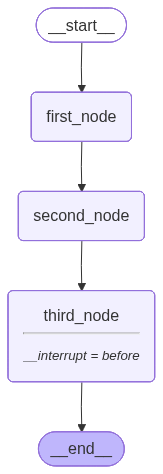

In [200]:
# let's interrupt the flow before third_node, so we can have human in the loop to pitch in and take some action before final approval.
intrptWithStateUpdateFlowApp = graph.compile(checkpointer=InMemorySaver(), interrupt_before=["third_node"]) # initialized that, flow must interrupt before third node
# let's visualize the graph flow
display(Image(intrptWithStateUpdateFlowApp.get_graph().draw_mermaid_png()))


In [201]:
input_text3 = {"messages": ["application for name update."]}

# now, before invoking, we must initialize the thread_id, which will be used to uniquely identify the execution
threadConfig3 = {"configurable": {"thread_id":"3"}}

output_text3 = intrptWithStateUpdateFlowApp.invoke(input_text3, threadConfig3)
print(output_text3)



{'messages': ['application for name update.', 'First Approval Status: Approved', 'Second Approval Status: Approved']}


nice, our flow has been interrupted at third node let's grab the checkpoint_id and update the state value and then resume the graph

In [202]:
intrptWithStateUpdateFlowApp.get_state(threadConfig3)

StateSnapshot(values={'messages': ['application for name update.', 'First Approval Status: Approved', 'Second Approval Status: Approved']}, next=('third_node',), config={'configurable': {'thread_id': '3', 'checkpoint_ns': '', 'checkpoint_id': '1f0bfae5-94f8-6dc6-8002-bd3a8fedccb7'}}, metadata={'source': 'loop', 'step': 2, 'parents': {}}, created_at='2025-11-12T09:59:59.208570+00:00', parent_config={'configurable': {'thread_id': '3', 'checkpoint_ns': '', 'checkpoint_id': '1f0bfae5-94f4-6e2e-8001-f87fa47bedda'}}, tasks=(PregelTask(id='27ae425f-d563-67fd-bccc-1448aa45a242', name='third_node', path=('__pregel_pull', 'third_node'), error=None, interrupts=(), state=None, result=None),), interrupts=())

In [203]:
thread3StateHistory = list(intrptWithStateUpdateFlowApp.get_state_history(threadConfig3))

In [204]:
# Let's write a logic to get the checkpoint_id for desired interruption point
checkpoint_id_for_update = ""
current_messages = []
checkpoint_config = {}
for item in thread3StateHistory:
  if item.next[0] == "third_node":
    # this is our node data
    print(item.config)
    print( item.values['messages'])
    current_messages  = item.values['messages']
    checkpoint_id_for_update = item.config['configurable']["checkpoint_id"]
    checkpoint_config = item.config
    break

{'configurable': {'thread_id': '3', 'checkpoint_ns': '', 'checkpoint_id': '1f0bfae5-94f8-6dc6-8002-bd3a8fedccb7'}}
['application for name update.', 'First Approval Status: Approved', 'Second Approval Status: Approved']


updating the state value now

In [205]:
current_messages[-1] = "Second Approval Status: Rejected"
current_messages

['application for name update.',
 'First Approval Status: Approved',
 'Second Approval Status: Rejected']

In [206]:
# while update we can also give custom new checkpoint id
intrptWithStateUpdateFlowApp.update_state(checkpoint_config, {"messages" :  current_messages})

{'configurable': {'thread_id': '3',
  'checkpoint_ns': '',
  'checkpoint_id': '1f0bfae5-958b-622d-8003-9d22125683f5'}}

Perfect!!!! Let's check the state and get the new checkpoint_id

In [207]:
intrptWithStateUpdateFlowApp.get_state(threadConfig3)

StateSnapshot(values={'messages': ['application for name update.', 'First Approval Status: Approved', 'Second Approval Status: Approved', 'application for name update.', 'First Approval Status: Approved', 'Second Approval Status: Rejected']}, next=('third_node',), config={'configurable': {'thread_id': '3', 'checkpoint_ns': '', 'checkpoint_id': '1f0bfae5-958b-622d-8003-9d22125683f5'}}, metadata={'source': 'update', 'step': 3, 'parents': {}}, created_at='2025-11-12T09:59:59.268478+00:00', parent_config={'configurable': {'thread_id': '3', 'checkpoint_ns': '', 'checkpoint_id': '1f0bfae5-94f8-6dc6-8002-bd3a8fedccb7'}}, tasks=(PregelTask(id='350d2635-5e8d-c056-eb73-2f784b506b83', name='third_node', path=('__pregel_pull', 'third_node'), error=None, interrupts=(), state=None, result=None),), interrupts=())

here, we saw new message has been appended to the existing one, becuase the State class has the operator as add for it, which is fine.

Either we can get the new checkpoint_id from update response or have a logic to get it.


In [208]:
thread3StateHistoryPostUpdate = list(intrptWithStateUpdateFlowApp.get_state_history(threadConfig3))
thread3StateHistoryPostUpdate

[StateSnapshot(values={'messages': ['application for name update.', 'First Approval Status: Approved', 'Second Approval Status: Approved', 'application for name update.', 'First Approval Status: Approved', 'Second Approval Status: Rejected']}, next=('third_node',), config={'configurable': {'thread_id': '3', 'checkpoint_ns': '', 'checkpoint_id': '1f0bfae5-958b-622d-8003-9d22125683f5'}}, metadata={'source': 'update', 'step': 3, 'parents': {}}, created_at='2025-11-12T09:59:59.268478+00:00', parent_config={'configurable': {'thread_id': '3', 'checkpoint_ns': '', 'checkpoint_id': '1f0bfae5-94f8-6dc6-8002-bd3a8fedccb7'}}, tasks=(PregelTask(id='350d2635-5e8d-c056-eb73-2f784b506b83', name='third_node', path=('__pregel_pull', 'third_node'), error=None, interrupts=(), state=None, result=None),), interrupts=()),
 StateSnapshot(values={'messages': ['application for name update.', 'First Approval Status: Approved', 'Second Approval Status: Approved']}, next=('third_node',), config={'configurable': {

In [209]:
# Let's write a logic to get the checkpoint_id for desired interruption point
new_checkpoint_id_for_resume = ""
for item in thread3StateHistoryPostUpdate:
  if item.next[0] == "third_node":
    # this is our node data
    print(item.config)
    new_checkpoint_id_for_resume = item.config['configurable']["checkpoint_id"]
    break

{'configurable': {'thread_id': '3', 'checkpoint_ns': '', 'checkpoint_id': '1f0bfae5-958b-622d-8003-9d22125683f5'}}


In [210]:
intrptWithStateUpdateFlowApp.invoke(None, {"thread_id":"3", "checkpoint_id":new_checkpoint_id_for_resume})

{'messages': ['application for name update.',
  'First Approval Status: Approved',
  'Second Approval Status: Approved',
  'application for name update.',
  'First Approval Status: Approved',
  'Second Approval Status: Rejected',
  'Final Status: Rejected']}

Superb!!!! 😍

Likewise we can update any state and resume the flow from there.